# Kaggle 房价预测实战


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from torch import nn
import torch
import util
from util import DATA_HUB, DATA_URL, download

读入并处理数据


In [2]:
DATA_HUB['kaggle_house_train'] = (
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce')
DATA_HUB['kaggle_house_test'] = (
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922aa8ee2eb90')

train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

print(train_data.shape)
print(test_data.shape)

正在从https://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_test.csv下载./data/kaggle_house_pred_test.csv...
(1460, 81)
(1459, 80)


简单检查数据


In [3]:
# 前 4 行的前 4 列和最后 3 列
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])
print(test_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000
     Id  MSSubClass MSZoning  LotFrontage  YrSold SaleType SaleCondition
0  1461          20       RH         80.0    2010       WD        Normal
1  1462          20       RL         81.0    2010       WD        Normal
2  1463          60       RL         74.0    2010       WD        Normal
3  1464          60       RL         78.0    2010       WD        Normal


id 不应该拟合，删除


In [4]:
# iloc[:, 1:-1] 取所有行，[1, -1)列，即去掉第一列和最后一列（id、价格label）
# iloc[:, 1:] 取所有行，[1, 结束)列，即去掉第一列（id）
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))

将缺失值替换为平均，特征重新缩放到 0 均值和单位方差


In [5]:
numeric_features = all_features.dtypes[all_features.dtypes != 'str'].index
# 标准化
all_features[numeric_features] = all_features[numeric_features].apply(lambda x: (x - x.mean()) / (x.std()))
# 将缺失值替换为 0（均值）
all_features[numeric_features] = all_features[numeric_features].fillna(0)

离散值用 one-hot 编码


In [6]:
# dummy_na=True 将缺失值也作为一个特征
all_features = pd.get_dummies(all_features, dummy_na=True, dtype=int)
all_features.shape # 特征变多了一些

(2919, 330)

从 pandas 的 dataframe 中提取 NumPy 数组，并转为 tensor


In [7]:
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(train_data.SalePrice.values, dtype=torch.float32).view(-1, 1) # view(-1, 1) 转为列向量

模型，几种对比

In [18]:
loss = nn.MSELoss() # 均方误差
in_features = train_features.shape[1] # 特征数

def get_net(**kwargs):
    """
    获取模型
    :param kind: 模型类型，'linear' 或 'mlp'
    :param layers: 隐藏层神经元数列表，默认 [256]
    :return: 模型
    """
    kind = kwargs.get('kind', 'linear') # 默认线性回归
    layers = kwargs.get('layers', [256]) # 默认双层mlp，隐藏层 256 个神经元
    net = None
    # 线性回归
    if kind == 'linear':
        net = nn.Linear(in_features, 1)
    # 多层感知机
    elif kind == 'mlp':
        dims = [in_features] + layers + [1]
        net = nn.Sequential()
        for i in range(len(dims) - 1):
            net.add_module(f'linear_{i}', nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                net.add_module(f'relu_{i}', nn.ReLU())
        def init_weights(m):
            if type(m) == nn.Linear:
                # xavier 初始化，均值为 0，方差为 2/(n_in+n_out)
                nn.init.normal_(m.weight, std=np.sqrt(2 / (m.in_features + m.out_features)))
        net.apply(init_weights)
    return net

这个场景更关心相对误差 $\frac{y-\hat{y}}{y}$，不被价格尺度影响，所以用对数差异


In [9]:
def log_rmse(net, features, labels):
    clipped_preds = torch.clamp(net(features), 1, float('inf')) # 将预测值限制在 [1, +∞) 区间，避免取对数时出现负数
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))
    return rmse.item()

用 adam 优化器训练


In [10]:
def train(net,
          train_features, train_labels,
          test_features, test_labels,
          num_epochs, batch_size,
          learning_rate: float = 0.01,
          weight_decay: float | int = 0):
    # 记录训练集和测试集的误差
    train_ls, test_ls = [], []
    # 训练集迭代器和优化器
    train_iter = util.load_array((train_features, train_labels), batch_size)
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            # 这里用 MSELoss 计算损失，log_rmse 只在记录误差时使用
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

k-fold 交叉验证，k=5


In [19]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k # 每折的大小
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size) # slice(start, stop)
        X_part, y_part = X[idx, :], y[idx]
        if j == i: # 第 i 折作为验证集
            X_valid, y_valid = X_part, y_part
        elif X_train is None: # 其他折作为训练集，第一次创建
            X_train, y_train = X_part, y_part
        else: # 其他折作为训练集，后续拼接
            X_train = torch.cat((X_train, X_part), dim=0)
            y_train = torch.cat((y_train, y_part), dim=0)
    return X_train, y_train, X_valid, y_valid

def k_fold(k,
           X_train, y_train,
           num_epochs, batch_size,
           learning_rate, weight_decay,
           **kwargs):
    train_l_sum, valid_l_sum = 0, 0 # 记录训练集和验证集的误差
    for i in range(k):
        # 创建数据和模型
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net(**kwargs)
        # 训练并记录误差
        train_ls, valid_ls = train(net, *data, num_epochs, batch_size, learning_rate, weight_decay)
        train_l_sum += train_ls[-1] # 记录最后一个 epoch 的误差
        valid_l_sum += valid_ls[-1]
        # 绘制第一个折的训练和验证误差曲线
        if i == 0:
            util.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                      xlabel='epoch', ylabel='log rmse', xlim=[1, num_epochs],
                      legend=['train', 'valid'], yscale='log')
        # 打印每折的误差
        print(f'fold {i + 1}, train log rmse {float(train_ls[-1]):f}, '
              f'valid log rmse {float(valid_ls[-1]):f}')
    # 返回平均误差
    return train_l_sum / k, valid_l_sum / k

在这里可以调参了


lr=5, weight_decay=0, kind=linear, layers=None
fold 1, train log rmse 0.149286, valid log rmse 0.146445
fold 2, train log rmse 0.145074, valid log rmse 0.162593
fold 3, train log rmse 0.143200, valid log rmse 0.149994
fold 4, train log rmse 0.148574, valid log rmse 0.145895
fold 5, train log rmse 0.143023, valid log rmse 0.173001
5-折验证: 平均训练 log rmse 0.145831, 平均验证 log rmse 0.155586

lr=5, weight_decay=0, kind=mlp, layers=[32]
fold 1, train log rmse 0.064428, valid log rmse 0.173620
fold 2, train log rmse 0.054594, valid log rmse 0.208562
fold 3, train log rmse 0.049757, valid log rmse 0.164170
fold 4, train log rmse 0.067940, valid log rmse 0.144012
fold 5, train log rmse 0.092283, valid log rmse 0.177836
5-折验证: 平均训练 log rmse 0.065800, 平均验证 log rmse 0.173640

lr=5, weight_decay=0, kind=mlp, layers=[128]
fold 1, train log rmse 0.052929, valid log rmse 0.154730
fold 2, train log rmse 0.075253, valid log rmse 0.154349
fold 3, train log rmse 0.063599, valid log rmse 0.169575
fold 4, train

,lr,weight_decay,kind,layers,train_log_rmse,valid_log_rmse
0,5.00,0.0,linear,None,0.145831,0.155586
1,5.00,0.0,mlp,[32],0.065800,0.173640
2,5.00,0.0,mlp,[128],0.065720,0.156077
3,5.00,0.0,mlp,"[64, 256]",1.538820,1.647424
4,5.00,0.1,linear,None,0.156056,0.169301
5,5.00,0.1,mlp,[32],0.064620,0.153185
6,5.00,0.1,mlp,[128],0.108799,0.280521
7,5.00,0.1,mlp,"[64, 256]",1.623464,1.831805
8,5.00,1.0,linear,None,0.330581,0.281179
9,5.00,1.0,mlp,[32],0.085299,0.162187


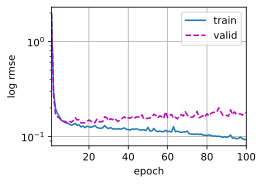

In [27]:
supparams = {
    'lr': [5, 0.1, 0.01],
    'weight_decay': [0, 0.1, 1],
    'kind': ['linear', 'mlp'],
    'layers': [[32], [128], [64, 256]]
}
k = 5
num_epochs = 100
batch_size = 32

records = pd.DataFrame(columns=['lr', 'weight_decay', 'kind', 'layers', 'train_log_rmse', 'valid_log_rmse'])

def train_attempt(lr, weight_decay, kind, layers=None):
    print(f'lr={lr}, weight_decay={weight_decay}, kind={kind}, layers={layers}')
    train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, batch_size, lr, weight_decay, kind=kind, layers=layers)
    print(f'{k}-折验证: 平均训练 log rmse {float(train_l):f}, 平均验证 log rmse {float(valid_l):f}\n')
    records.loc[len(records)] = [lr, weight_decay, kind, layers, train_l, valid_l]

for lr in supparams['lr']:
    for weight_decay in supparams['weight_decay']:
        for kind in supparams['kind']:
            if kind == 'linear':
                train_attempt(lr, weight_decay, kind)
            else:
                for layers in supparams['layers']:
                    train_attempt(lr, weight_decay, kind, layers)
records

最后完整训练一次，提交预测结果


In [29]:
def train_and_pred(train_features, test_features,
                   train_labels, test_data,
                   num_epochs, batch_size,
                   lr, weight_decay,
                   **kwargs):
    net = get_net(**kwargs)
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, batch_size, lr, weight_decay)
    print(f'训练 log rmse {float(train_ls[-1]):f}')
    # 预测
    preds = net(test_features).detach().numpy()
    # 将预测结果写入文件
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1) # 只保留 id 和预测价格
    submission.to_csv('./results/kaggle_house_price.csv', index=False)

final_lr = 0.01
final_weight_decay = 1
final_kind = 'mlp'
final_layers = [128]
train_and_pred(train_features, test_features,
               train_labels, test_data,
               num_epochs, batch_size,
               final_lr, final_weight_decay,
               kind=final_kind, layers=final_layers)

训练 log rmse 0.120354
